# 1 · Preprocess the forest inventory for CBM-CFS3

Turns each forest management unit's **Forest Resource Inventory (FRI)** into the seven tables the CBM-CFS3 **Standard Import Tool (SIT)** reads, and splits them into stacks that are simulated separately.

| Step | What happens |
|---|---|
| 1 | Keep productive forest polygons (`POLYTYPE = FOR`) |
| 2 | Move stand age to 2000 (`OAGE + 2000 − YRSOURCE`; stands younger than that start at 100) and place each depletion in its time step (`YRDEP − 2000`) |
| 3 | Assign a species group from `OSPCOMP`: softwood or hardwood, split by area when the second-listed species is in the other group and makes up ≥ 40% |
| 4 | Build the SIT tables: age classes, classifiers, disturbance types, inventory, yield, transition rules, events |
| 5 | Split the inventory into three stacks and write each one, with `mapping.json`, to its own folder |

**Input**: the FRI 2D polygon attribute table for each forest, as `.csv`, `.dbf` or a geodatabase layer, in `data/fri/`.
**Output**: `runs/<forest>/stack<n>/sit_*.csv` and `mapping.json`, ready for notebook 2.

In [1]:
import json
import os
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
RUNS = Path(os.environ.get('CBM_RUNS_DIR', ROOT / 'runs'))   # one folder per forest, one sub-folder per stack

DATA = ROOT / 'data'

FORESTS = {
    'wabigoon':  dict(name='Wabigoon Forest (130)',   inventory=DATA / 'fri' / 'wabigon_2D_db.csv',   layer=None),
    'troutlake': dict(name='Trout Lake Forest (120)', inventory=DATA / 'fri' / 'troutlake_2D_db.csv', layer=None),
}
START_YEAR = 2000
N_STACKS = 3

## Rules

The species lists, disturbance codes, age classes and the two yield curves used for every stand. The yield curves are merchantable volume (m³/ha) at ages 0, 10, … 210.

In [2]:
SOFTWOODS = {'CE', 'CR', 'CW', 'SX', 'SB', 'SR', 'SW', 'JP', 'WP', 'BF', 'PJ', 'LA', 'PW', 'PR'}
HARDWOODS = {'AW', 'AB', 'BG', 'BW', 'BY', 'PT', 'PL', 'BE', 'BD', 'PB', 'PO', 'MR'}

DISTURBANCE_TYPES = {'HARVEST': 'DISTID0', 'FIRE': 'DISTID1', 'BLOWDOWN': 'DISTID2',
                     'DROUGHT': 'DISTID3', 'DISEASE': 'DISTID4', 'FLOOD': 'DISTID5'}
N_AGE_CLASSES = 22                     # AGEID0 (size 0) and AGEID1-21 (10 years each)

YIELD_CURVES = {
    'SW': [0, 3, 12, 28, 45, 62, 78, 92, 105, 115, 120, 124, 127, 129, 130, 130, 130, 130, 130, 130, 130, 130],
    'HW': [0, 2, 10, 25, 40, 55, 70, 85, 100, 115, 125, 130, 135, 138, 140, 142, 143, 143, 143, 143, 143, 143],
}

# how CBM-CFS3 should read our codes: default species, spatial unit and disturbance types
MAPPING = {
    'nonforest': None,
    'species': {'species_classifier': 'species',
                'species_mapping': [{'user_species': 'Softwood', 'default_species': 'Unspecified softwood species'},
                                    {'user_species': 'Hardwood', 'default_species': 'Unspecified hardwood species'}]},
    'spatial_units': {'mapping_mode': 'SingleDefaultSpatialUnit', 'default_spuid': 16},   # Ontario, Boreal Shield West
    'disturbance_types': {'disturbance_type_mapping': [
        {'user_dist_type': 'HARVEST', 'default_dist_type': 'Clear-cut with slash-burn'},
        {'user_dist_type': 'FIRE', 'default_dist_type': 'Wildfire'},
        {'user_dist_type': 'BLOWDOWN', 'default_dist_type': 'Unknown'},
        {'user_dist_type': 'DROUGHT', 'default_dist_type': 'Unknown'},
        {'user_dist_type': 'DISEASE', 'default_dist_type': 'Insect disturbance'},
        {'user_dist_type': 'FLOOD', 'default_dist_type': 'Unknown'}]},
}


def group_of(code):
    code = code.upper()
    return 'SW' if code in SOFTWOODS else 'HW' if code in HARDWOODS else 'UNKNOWN'


def species_groups(ospcomp, area_ha):
    """Split one stand into softwood / hardwood rows from its composition string, e.g. 'Sb  60Pt  40'."""
    comp = str(ospcomp).replace(' ', '')
    if len(comp) <= 5:                                   # a single species, e.g. 'Sb100'
        return [(group_of(comp[:2]), area_ha)]
    species, i = [], 0
    while i < len(comp):                                 # two-letter code followed by its percentage
        code, i, pct = comp[i:i + 2], i + 2, ''
        while i < len(comp) and comp[i].isdigit():
            pct, i = pct + comp[i], i + 1
        species.append((code, int(pct) if pct else 0))
    first = group_of(species[0][0])
    second = group_of(species[1][0]) if len(species) > 1 else None
    if second and first != second and species[1][1] >= 40:
        sw = sum(p for c, p in species if group_of(c) == 'SW')
        hw = sum(p for c, p in species if group_of(c) == 'HW')
        return [(g, area_ha * pct / 100) for g, pct in (('SW', sw), ('HW', hw)) if pct > 0]
    return [(first, area_ha)]


def age_class(age):
    return f'AGEID{min(int(age) // 10 + 1, N_AGE_CLASSES - 1)}'

## Read the inventory

`load_inventory` accepts a CSV or DBF export of the 2D layer, or the geodatabase layer itself (needs `pyogrio` and `geopandas`). Areas come from the `Area` field in m², or from the polygon geometry.

In [3]:
def load_inventory(path, layer=None):
    path = Path(path)
    if path.suffix.lower() == '.csv':
        return pd.read_csv(path, low_memory=False)
    if path.suffix.lower() == '.dbf':
        from dbfread import DBF
        return pd.DataFrame(iter(DBF(path, load=True)))
    import pyogrio
    gdf = pyogrio.read_dataframe(path, layer=layer)
    gdf['Area'] = gdf.geometry.area
    return pd.DataFrame(gdf.drop(columns='geometry'))


def prepare_stands(fri):
    stands = fri[fri.POLYTYPE.astype(str).str.strip().eq('FOR')].copy()
    age = START_YEAR - stands.YRSOURCE.astype(int) + stands.OAGE.astype(int)
    stands['age2000'] = age.where(age > 0, 100)
    yrdep = pd.to_numeric(stands.YRDEP, errors='coerce')
    stands['step'] = (yrdep - START_YEAR).where(yrdep > START_YEAR)
    stands['area_ha'] = stands.Area / 10_000
    stands['PolyId'] = 'Polygon' + stands.POLYID.astype(str).str.replace('-', '', regex=False)
    stands['dist'] = stands.DEPTYPE.fillna('').astype(str).str.strip().str.upper().map(DISTURBANCE_TYPES).fillna('')
    shared = stands.PolyId[stands.PolyId.duplicated()].unique()
    if len(shared):     # kept: CBM-CFS3 adds rows with the same classifiers into one stand
        print(f'  {len(shared)} POLYID values are used by more than one forest polygon: {list(shared)[:5]}')
    return stands

## Build the SIT tables

One inventory row per stand and species group. A transition rule and an event are written for every stand with a depletion after 2000: the event fires in its time step, and the rule sends the stand back to age 0 in the same species group.

In [4]:
EVENT_FILTERS = ['MinimumYearsSinceLastDisturbance', 'MaximumYearsSinceLastDisturbance', 'LastDisturbanceTypeID',
                 'MinTotalBiomassC', 'MaxTotalBiomassC', 'MinMerchantableSWBiomassC', 'MaxMerchantableSWBiomassC',
                 'MinMerchantableHWBiomassC', 'MaxMerchantableHWBiomassC', 'MinTotalStemSnagC', 'MaxTotalStemSnagC',
                 'MinTotalSWSnagC', 'MaxTotalSWSnagC', 'MinTotalHWSnagC', 'MaxTotalHWSnagC',
                 'MinTotalMerchantableSnagC', 'MaxTotalMerchantableSnagC', 'MinMerchantableSWSnagC',
                 'MaxMerchantableSWSnagC', 'MinMerchantableHWSnagC', 'MaxMerchantableHWSnagC']


def build_tables(stands):
    rows, unknown = [], Counter()
    for s in stands.itertuples():
        for group, area in species_groups(s.OSPCOMP, s.area_ha):
            if group == 'UNKNOWN':
                unknown[str(s.OSPCOMP)] += 1
                continue
            rows.append(dict(SpeciesGroup=group, PolyId=s.PolyId, UsingID=True, Age=age_class(s.age2000), Area=area,
                             Delay=0, UNFCCCL=0, HistDist=s.dist, LastDist=s.dist, step=s.step))
    inv = pd.DataFrame(rows)
    if unknown:
        print(f'  skipped {sum(unknown.values())} rows with unrecognised species, e.g. {unknown.most_common(3)}')

    yld = inv[['SpeciesGroup', 'PolyId']].rename(columns={'SpeciesGroup': 'Species'})
    yld['leading'] = yld.Species
    vols = pd.DataFrame([YIELD_CURVES[g] for g in yld.Species], columns=[f'vol{i}' for i in range(N_AGE_CLASSES)], index=yld.index)
    yld = pd.concat([yld, vols], axis=1)

    hit = inv[inv.HistDist.ne('') & inv.step.notna()]
    n = hit.Age.str.replace('AGEID', '').astype(int)
    lo, hi = 'AGEID' + (n - 1).clip(lower=0).astype(str), 'AGEID' + (n + 1).astype(str)
    sw = hit.SpeciesGroup.eq('SW')
    trans = pd.DataFrame(dict(Species=hit.SpeciesGroup, PolyId=hit.PolyId, UsingID=True,
                              SWStart=lo.where(sw, 'AGEID0'), SWEnd=hi.where(sw, 'AGEID0'),
                              HWStart=lo.where(~sw, 'AGEID0'), HWEnd=hi.where(~sw, 'AGEID0'),
                              DisturbanceID=hit.HistDist, PostClassifier1=hit.SpeciesGroup, PostClassifier2=hit.PolyId,
                              RegenDelay=0, ResetAge=0, Percent=100))

    last = f'AGEID{N_AGE_CLASSES - 1}'
    events = pd.DataFrame(dict(species=hit.SpeciesGroup, PolyId=hit.PolyId, UsingID=True,
                               SWStart='AGEID0', SWEnd=last, HWStart='AGEID0', HWEnd=last))
    for col in EVENT_FILTERS:
        events[col] = -1
    events = events.assign(Efficiency=1, SortType=1, MeasurementType='P', Amount=1,
                           disturbance_type_id=hit.HistDist, step=hit.step.astype(int))
    return inv.drop(columns='step'), yld, trans, events


def classifier_table(poly_ids):
    head = pd.DataFrame([(1, '_CLASSIFIER', 'species'), (1, 'SW', 'Softwood'), (1, 'HW', 'Hardwood'), (2, '_CLASSIFIER', 'PolygonID')],
                        columns=['ClassifierNumber', 'ClassifierValueID', 'Name'])
    ids = pd.unique(pd.Series(poly_ids))
    body = pd.DataFrame(dict(ClassifierNumber=2, ClassifierValueID=ids, Name=['Polygon ' + i for i in ids]))
    return pd.concat([head, body], ignore_index=True)


AGE_CLASSES = pd.DataFrame(dict(age_class_id=[f'AGEID{i}' for i in range(N_AGE_CLASSES)], size=[0] + [10] * (N_AGE_CLASSES - 1)))
DIST_TYPES = pd.DataFrame(dict(disturbance_type_id=list(DISTURBANCE_TYPES.values()), name=list(DISTURBANCE_TYPES)))

## Split into stacks and write

Large inventories are simulated in stacks to keep each Access database a manageable size. **Every stack gets its own folder**: the import in notebook 2 reads one folder per stack, so a stack can never be imported from another stack's tables.

In [5]:
def write_stacks(key, inv, yld, trans, events):
    summary = []
    for i, rows in enumerate(np.array_split(np.arange(len(inv)), N_STACKS), start=1):   # equal row counts, inventory order
        part = inv.iloc[rows]
        ids = set(part.PolyId)
        folder = RUNS / key / f'stack{i}'
        folder.mkdir(parents=True, exist_ok=True)
        part.to_csv(folder / 'sit_inventory.csv', index=False)
        yld[yld.PolyId.isin(ids)].to_csv(folder / 'sit_yield.csv', index=False)
        trans[trans.PolyId.isin(ids)].to_csv(folder / 'sit_transitions.csv', index=False)
        events[events.PolyId.isin(ids)].to_csv(folder / 'sit_events.csv', index=False)
        classifier_table(part.PolyId).to_csv(folder / 'sit_classifiers.csv', index=False)
        AGE_CLASSES.to_csv(folder / 'sit_age_classes.csv', index=False)
        DIST_TYPES.to_csv(folder / 'sit_disturbance_types.csv', index=False)
        (folder / 'mapping.json').write_text(json.dumps(MAPPING, indent=2))
        summary.append(dict(forest=key, stack=i, inventory_rows=len(part), area_ha=round(part.Area.sum()),
                            events=int(events.PolyId.isin(ids).sum()), folder=str(folder.relative_to(RUNS))))
    return summary


summary, tables = [], {}
for key, cfg in FORESTS.items():
    fri = load_inventory(cfg['inventory'], cfg['layer'])
    stands = prepare_stands(fri)
    inv, yld, trans, events = build_tables(stands)
    tables[key] = dict(stands=stands, inventory=inv, events=events)
    print(f"{cfg['name']}: {len(fri):,} polygons, {len(stands):,} forest stands, {len(inv):,} inventory rows "
          f"({(inv.SpeciesGroup == 'SW').sum():,} SW, {(inv.SpeciesGroup == 'HW').sum():,} HW), "
          f"{inv.Area.sum():,.0f} ha, {len(events):,} events")
    summary += write_stacks(key, inv, yld, trans, events)

pd.DataFrame(summary)

  2 POLYID values are used by more than one forest polygon: ['Polygon38899', 'Polygon58624']


Wabigoon Forest (130): 68,703 polygons, 43,476 forest stands, 44,258 inventory rows (33,468 SW, 10,790 HW), 579,007 ha, 3,180 events


Trout Lake Forest (120): 83,831 polygons, 54,886 forest stands, 55,856 inventory rows (51,554 SW, 4,302 HW), 823,108 ha, 3,075 events


,forest,stack,inventory_rows,area_ha,events,folder
0,wabigoon,1,14753,175656,393,wabigoon\stack1
1,wabigoon,2,14753,235856,1275,wabigoon\stack2
2,wabigoon,3,14752,167495,1512,wabigoon\stack3
3,troutlake,1,18619,451605,1278,troutlake\stack1
4,troutlake,2,18619,231716,810,troutlake\stack2
5,troutlake,3,18618,139787,987,troutlake\stack3


## What goes into the model

Forest area by stand age in 2000, and disturbed area by year and type, per forest.

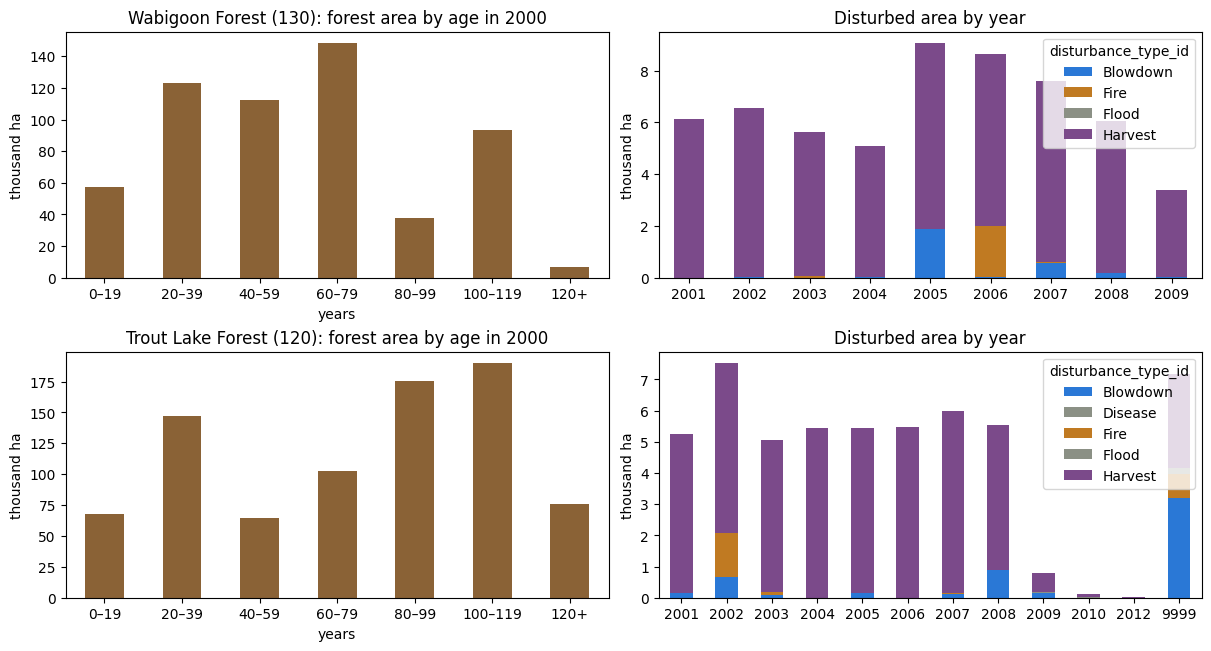

In [6]:
import matplotlib.pyplot as plt

NAMES = {v: k.title() for k, v in DISTURBANCE_TYPES.items()}
fig, axes = plt.subplots(len(FORESTS), 2, figsize=(12, 3.2 * len(FORESTS)), constrained_layout=True)
for row, (key, t) in zip(np.atleast_2d(axes), tables.items()):
    s = t['stands']
    bins = pd.cut(s.age2000, list(range(0, 130, 20)) + [1000], right=False,
                  labels=['0–19', '20–39', '40–59', '60–79', '80–99', '100–119', '120+'])
    (s.groupby(bins, observed=False).area_ha.sum() / 1000).plot.bar(ax=row[0], color='#8a6236', rot=0)
    row[0].set(title=f"{FORESTS[key]['name']}: forest area by age in 2000", xlabel='years', ylabel='thousand ha')
    ev = t['events'].merge(t['inventory'][['SpeciesGroup', 'PolyId', 'Area']], left_on=['species', 'PolyId'],
                           right_on=['SpeciesGroup', 'PolyId'])
    by_year = ev.pivot_table(index=ev.step + START_YEAR, columns=ev.disturbance_type_id.map(NAMES), values='Area', aggfunc='sum').fillna(0)
    colours = [{'Harvest': '#7b4a8a', 'Fire': '#c07a22', 'Blowdown': '#2a78d6'}.get(c, '#8b9085') for c in by_year.columns]
    (by_year / 1000).plot.bar(ax=row[1], stacked=True, rot=0, color=colours)
    row[1].set(title='Disturbed area by year', xlabel='', ylabel='thousand ha')
plt.show()